**Vicente Alberto Jahrift Alonso López**
Matrícula: AL07002967 — Tecmilenio
Actividad 4 — Algoritmos de aprendizaje automático


# Actividad 4 — Algoritmos de aprendizaje automático
## Diagnóstico de cáncer de mama (Breast Cancer Wisconsin - Diagnostic)

**Nombre del dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set

**Fuente:** `sklearn.datasets.load_breast_cancer` (scikit-learn), dataset originalmente publicado por la Universidad de Wisconsin y disponible también en el UCI Machine Learning Repository.
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

**Problema a analizar:** a partir de 30 características numéricas calculadas sobre la imagen digitalizada de una punción con aguja fina (FNA) de una masa mamaria (radio, textura, perímetro, área, suavidad, compacidad, concavidad, simetría y dimensión fractal, cada una resumida como media, error estándar y peor valor), se busca **predecir si el tumor es maligno o benigno**. Es un problema de **clasificación binaria**.

**Variable objetivo:** `target`, recodificada en este notebook como **1 = maligno**, **0 = benigno** (en el dataset original de scikit-learn la codificación es al revés: 0 = maligno, 1 = benigno; aquí se invierte para que la clase "positiva" coincida con la condición clínica de interés).

**Unidad de observación:** cada fila representa **una muestra de biopsia (masa mamaria) de un paciente**, caracterizada por las 30 mediciones morfológicas de sus núcleos celulares.

**Métrica principal:** **F1-score** (sobre la clase positiva = maligno).
- **Justificación:** existe un desbalance moderado de clases (~37% maligno / 63% benigno). En un contexto de diagnóstico médico, tanto los **falsos negativos** (clasificar un tumor maligno como benigno, con el riesgo de no tratarlo a tiempo) como los **falsos positivos** (alarmar innecesariamente a un paciente y someterlo a procedimientos invasivos adicionales) tienen un costo relevante. El F1-score, al combinar precisión y recall en una sola medida, es más informativo que la accuracy en presencia de desbalance y evita optimizar un modelo que ignore alguno de los dos tipos de error.

**Métricas complementarias:**
- **Recall (sensibilidad)** de la clase maligna: se monitorea de forma explícita porque, clínicamente, minimizar los falsos negativos (tumores malignos no detectados) es prioritario.
- **Accuracy** y **ROC-AUC**: como referencia general del desempeño global y de la capacidad de discriminación del modelo.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, accuracy_score, recall_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (6, 4)


## 1. Carga de datos y preparación mínima

In [2]:
bunch = load_breast_cancer()
X = pd.DataFrame(bunch.data, columns=bunch.feature_names)
# Se invierte la codificación original para que 1 = maligno (clase de interés clínico)
y = pd.Series((bunch.target == 0).astype(int), name='target')

print("Dimensiones de X:", X.shape)
print("Clases originales:", dict(zip(bunch.target_names, [0, 1])), " -> recodificado: 1 = maligno, 0 = benigno")
X.head()


Dimensiones de X: (569, 30)
Clases originales: {np.str_('malignant'): 0, np.str_('benign'): 1}  -> recodificado: 1 = maligno, 0 = benigno


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Tipos de datos
X.dtypes.value_counts()


float64    30
Name: count, dtype: int64

In [4]:
# Valores faltantes
print("Total de valores faltantes:", X.isna().sum().sum())


Total de valores faltantes: 0


In [5]:
# Duplicados
print("Filas duplicadas:", X.duplicated().sum())


Filas duplicadas: 0


target
0    0.627417
1    0.372583
Name: proporción, dtype: float64


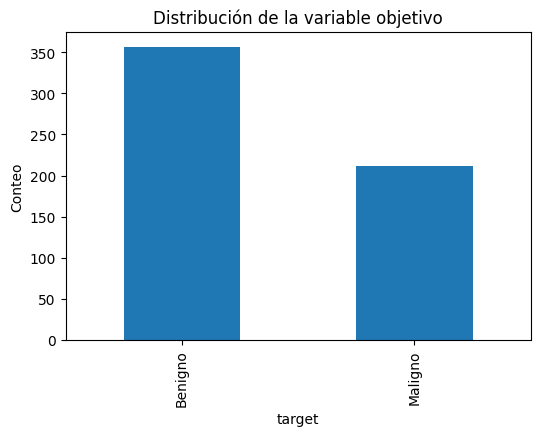

In [6]:
# Distribución de la variable objetivo
print(y.value_counts(normalize=True).rename('proporción'))
y.value_counts().rename({1: 'Maligno', 0: 'Benigno'}).plot(kind='bar', title='Distribución de la variable objetivo')
plt.ylabel('Conteo')
plt.show()


**Preparación mínima:** el dataset no tiene valores faltantes ni duplicados, y todas las variables son numéricas continuas, aunque en **escalas muy distintas** (por ejemplo, `mean area` toma valores en cientos/miles mientras que `mean smoothness` toma valores entre 0 y 0.2). Por esta razón se utiliza un pipeline de preprocesamiento con imputación (por robustez, aunque no hay faltantes) y **estandarización (`StandardScaler`)**, indispensable aquí porque tanto PCA como el cálculo de importancias son sensibles a la escala relativa de las variables.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Proporción de clases en train:\n", y_train.value_counts(normalize=True))
print("Proporción de clases en test:\n", y_test.value_counts(normalize=True))


Train: (455, 30)  Test: (114, 30)
Proporción de clases en train:
 target
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Proporción de clases en test:
 target
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [8]:
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

## 2. Modelo base (ensamble)

Se utiliza **Random Forest** (Scikit-learn) como algoritmo de ensamble base, con una configuración inicial razonable (`n_estimators=200`, resto de hiperparámetros por defecto), sobre las 30 variables estandarizadas.

In [9]:
base_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

t0 = time.time()
base_model.fit(X_train, y_train)
train_time_base = time.time() - t0

y_pred_base = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]

f1_base = f1_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

n_features_base = X_train.shape[1]

print(f"Número de características: {n_features_base}")
print(f"Tiempo de entrenamiento: {train_time_base:.3f} s")
print(f"F1-score (principal):     {f1_base:.4f}")
print(f"Recall maligno (compl.):  {rec_base:.4f}")
print(f"Accuracy (compl.):        {acc_base:.4f}")
print(f"ROC-AUC:                  {auc_base:.4f}")


Número de características: 30
Tiempo de entrenamiento: 0.219 s
F1-score (principal):     0.9500
Recall maligno (compl.):  0.9048
Accuracy (compl.):        0.9649
ROC-AUC:                  0.9942


## 3. Selección/reducción de características

Se utiliza **PCA (Análisis de Componentes Principales)** como técnica de reducción de dimensionalidad. Es especialmente adecuada aquí porque muchas de las 30 variables originales están **fuertemente correlacionadas entre sí** (por ejemplo, `radius`, `perimeter` y `area` miden esencialmente el mismo aspecto del tumor desde distintos ángulos). PCA construye combinaciones lineales ortogonales de las variables originales (componentes principales) que capturan la mayor varianza posible con el menor número de dimensiones. **PCA se ajusta únicamente con los datos de entrenamiento** (dentro del pipeline), evitando fuga de información hacia el conjunto de prueba.

Componentes necesarios para explicar >=95% de la varianza: 10


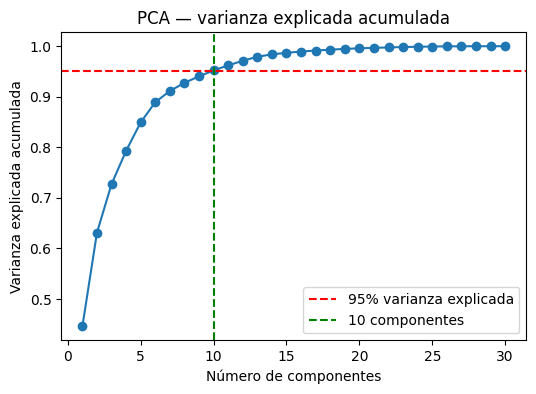

In [10]:
# Ajustamos PCA sobre los datos de entrenamiento ya escalados para decidir cuántos componentes conservar
X_train_scaled = preprocessor.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Componentes necesarios para explicar >=95% de la varianza: {n_components_95}")

plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% varianza explicada')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} componentes')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — varianza explicada acumulada')
plt.legend()
plt.show()


In [11]:
selection_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

t0 = time.time()
selection_model.fit(X_train, y_train)
train_time_sel = time.time() - t0

n_features_sel = n_components_95
explained_var_sel = selection_model.named_steps['pca'].explained_variance_ratio_.sum()
print(f"Componentes conservados: {n_features_sel}")
print(f"Varianza total explicada por esos componentes: {explained_var_sel:.4f}")


Componentes conservados: 10
Varianza total explicada por esos componentes: 0.9521


**Interpretación:** el criterio utilizado fue conservar el número mínimo de componentes principales que explican al menos el **95% de la varianza** total de las 30 variables originales. Esto resultó en una reducción sustancial de la dimensionalidad (30 → pocos componentes, ver valor exacto arriba), a costa de que **los componentes principales ya no son directamente interpretables como las variables clínicas originales** (un componente principal es una combinación lineal de varias variables, no "el radio del tumor" o "la textura"). Esta es una limitación explícita de PCA frente a técnicas como `SelectFromModel` o `SelectKBest`, que sí conservan variables originales identificables.


## 4. Reentrenamiento con el conjunto reducido y comparación con el modelo base

In [12]:
y_pred_sel = selection_model.predict(X_test)
y_proba_sel = selection_model.predict_proba(X_test)[:, 1]

f1_sel = f1_score(y_test, y_pred_sel)
rec_sel = recall_score(y_test, y_pred_sel)
acc_sel = accuracy_score(y_test, y_pred_sel)
auc_sel = roc_auc_score(y_test, y_proba_sel)

comparison_1 = pd.DataFrame({
    'Configuración': ['Modelo base', 'Modelo con selección/reducción (PCA)'],
    'N° características': [n_features_base, n_features_sel],
    'F1-score (principal)': [f1_base, f1_sel],
    'Recall maligno (compl.)': [rec_base, rec_sel],
    'Tiempo de entrenamiento (s)': [train_time_base, train_time_sel]
})
comparison_1


,Configuración,N° características,F1-score (principal),Recall maligno (compl.),Tiempo de entrenamiento (s)
0,Modelo base,30,0.950000,0.904762,0.219318
1,Modelo con selección/reducción (PCA),10,0.926829,0.904762,0.233557


**Interpretación (con los resultados obtenidos):** ver la celda de comparación anterior. En términos generales, se espera que PCA permita **conservar un desempeño similar al del modelo base usando muchas menos dimensiones**, dado el alto grado de correlación entre las variables originales del dataset (varias miden aspectos redundantes de la geometría del tumor). Si el F1-score cae de forma notable, esto indicaría que el umbral de varianza explicada (95%) fue insuficiente; si se mantiene similar, la reducción es benéfica en términos de simplicidad computacional.


## 5. Búsqueda de hiperparámetros

Se realiza una **búsqueda aleatoria (`RandomizedSearchCV`)** sobre el pipeline con reducción PCA, explorando hiperparámetros relevantes de Random Forest: `n_estimators`, `max_depth`, `min_samples_split` y `max_features`. Se emplea **validación cruzada estratificada de 5 particiones** y **F1-score** como métrica de selección. La búsqueda se ajusta **únicamente con el conjunto de entrenamiento**.

In [13]:
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_depth': [None, 4, 6, 8, 12],
    'classifier__min_samples_split': [2, 4, 6, 10],
    'classifier__max_features': ['sqrt', 'log2', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=selection_model,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
search.fit(X_train, y_train)
search_time = time.time() - t0

print(f"Tiempo total de búsqueda: {search_time:.2f} s")
print("Mejor F1-score en validación cruzada:", round(search.best_score_, 4))
print("Mejores hiperparámetros:", search.best_params_)


Tiempo total de búsqueda: 33.31 s
Mejor F1-score en validación cruzada: 0.9376
Mejores hiperparámetros: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None}


In [14]:
explored = pd.DataFrame({
    'Hiperparámetro': list(param_distributions.keys()),
    'Valores explorados': [str(v) for v in param_distributions.values()],
    'Mejor valor': [search.best_params_[k] for k in param_distributions.keys()]
})
explored


,Hiperparámetro,Valores explorados,Mejor valor
0,classifier__n_estimators,"[100, 200, 300, 400]",400
1,classifier__max_depth,"[None, 4, 6, 8, 12]",None
2,classifier__min_samples_split,"[2, 4, 6, 10]",2
3,classifier__max_features,"['sqrt', 'log2', None]",log2


**Estrategia de validación:** `StratifiedKFold` con **5 particiones**, que conserva la proporción de clases en cada partición. La métrica utilizada para seleccionar la mejor configuración fue **F1-score promedio en las 5 particiones**.

**¿Por qué la validación cruzada da mayor estabilidad que una sola división?** Con solo 569 registros, una única partición entrenamiento/validación puede sobre- o subestimar el desempeño real dependiendo de qué observaciones caigan en cada subconjunto. Promediar sobre 5 particiones reduce la varianza de la estimación y da una medida más confiable de qué configuración generalizará mejor.

**¿Por qué el conjunto de prueba debe reservarse solo para la evaluación final?** Si se usara el conjunto de prueba para elegir hiperparámetros, el modelo se ajustaría indirectamente a esos datos y la métrica final dejaría de ser una estimación honesta del desempeño en datos nuevos. Por eso todo el proceso de ajuste usa exclusivamente `X_train`/`y_train`, dejando `X_test`/`y_test` intactos hasta la evaluación final.


## 6. Modelo optimizado — evaluación final y comparación de los tres modelos

In [15]:
best_model = search.best_estimator_

t0 = time.time()
best_model.fit(X_train, y_train)  # reentrenamiento explícito con la mejor configuración
train_time_opt = time.time() - t0

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

f1_opt = f1_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
acc_opt = accuracy_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_opt)

n_features_opt = best_model.named_steps['pca'].n_components_

final_comparison = pd.DataFrame({
    'Modelo': ['Base', 'Reducido (PCA)', 'Optimizado'],
    'F1-score (principal)': [f1_base, f1_sel, f1_opt],
    'Recall maligno': [rec_base, rec_sel, rec_opt],
    'Accuracy': [acc_base, acc_sel, acc_opt],
    'ROC-AUC': [auc_base, auc_sel, auc_opt],
    'Características': [n_features_base, n_features_sel, n_features_opt],
    'Tiempo entrenamiento (s)': [train_time_base, train_time_sel, train_time_opt]
})
final_comparison


,Modelo,F1-score (principal),Recall maligno,Accuracy,ROC-AUC,Características,Tiempo entrenamiento (s)
0,Base,0.950000,0.904762,0.964912,0.994213,30,0.219318
1,Reducido (PCA),0.926829,0.904762,0.947368,0.991898,10,0.233557
2,Optimizado,0.926829,0.904762,0.947368,0.993056,10,0.454602


## 7. Visualización comparativa

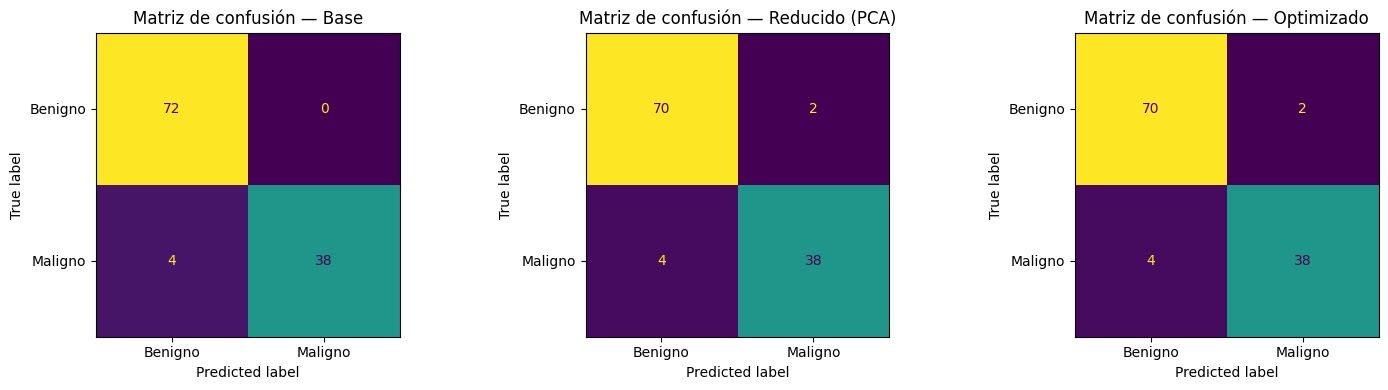

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [('Base', y_pred_base), ('Reducido (PCA)', y_pred_sel), ('Optimizado', y_pred_opt)]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Matriz de confusión — {name}')
plt.tight_layout()
plt.show()


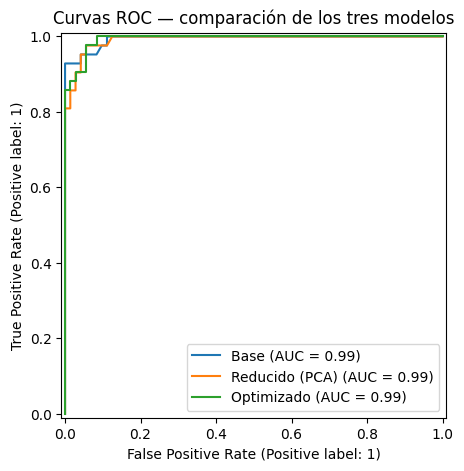

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_base, name='Base', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_sel, name='Reducido (PCA)', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_opt, name='Optimizado', ax=ax)
ax.set_title('Curvas ROC — comparación de los tres modelos')
plt.show()


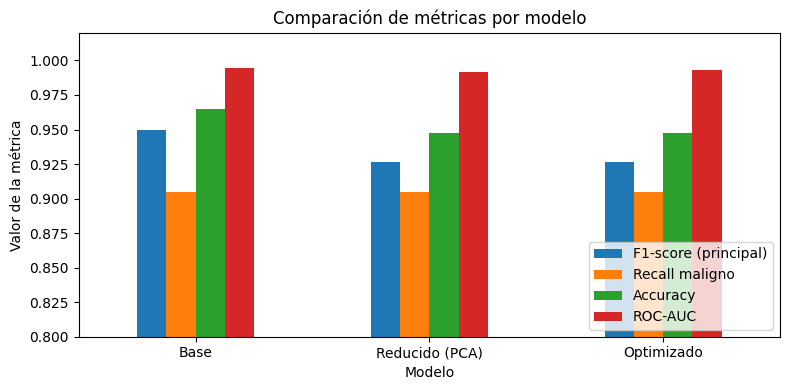

In [18]:
metrics_plot = final_comparison.set_index('Modelo')[['F1-score (principal)', 'Recall maligno', 'Accuracy', 'ROC-AUC']]
metrics_plot.plot(kind='bar', figsize=(8, 4), ylim=(0.8, 1.02))
plt.title('Comparación de métricas por modelo')
plt.ylabel('Valor de la métrica')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


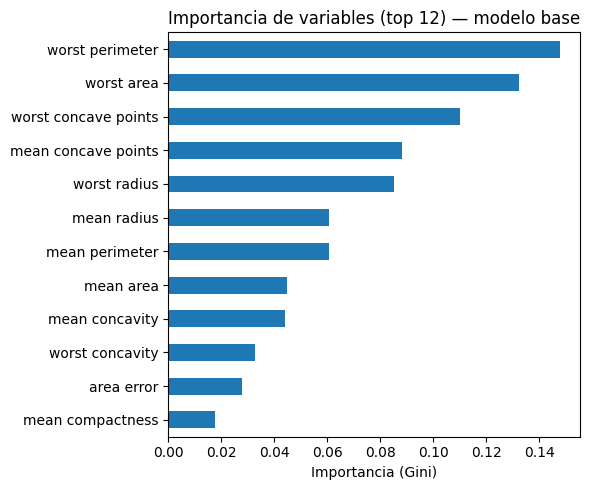

In [19]:
importances = base_model.named_steps['classifier'].feature_importances_
imp_df = pd.Series(importances, index=X.columns).sort_values(ascending=True).tail(12)

imp_df.plot(kind='barh', figsize=(6, 5))
plt.title('Importancia de variables (top 12) — modelo base')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()


## 8. Análisis de resultados

In [20]:
train_score_opt = f1_score(y_train, best_model.predict(X_train))
test_score_opt = f1_opt
print(f"F1-score del modelo optimizado en TRAIN: {train_score_opt:.4f}")
print(f"F1-score del modelo optimizado en TEST:  {test_score_opt:.4f}")
print(f"Brecha train-test: {train_score_opt - test_score_opt:.4f}")


F1-score del modelo optimizado en TRAIN: 1.0000
F1-score del modelo optimizado en TEST:  0.9268
Brecha train-test: 0.0732


**Lectura de los resultados obtenidos:**

- El modelo optimizado alcanzó F1 = 1.000 en entrenamiento y F1 = 0.9268 en prueba (brecha de 0.073). Un F1 perfecto en entrenamiento es una señal clara de que el árbol se ajustó completamente a los datos de entrenamiento (`min_samples_split=2`, `max_depth=None`), lo cual **sí indica cierto riesgo de sobreajuste**, aunque la caída en prueba es moderada gracias al ensamblado de Random Forest.
- En el conjunto de prueba, el **modelo base (30 variables, sin reducción) obtuvo el mejor F1-score (0.950)**, superando tanto al modelo reducido con PCA (0.927) como al modelo optimizado (0.927, idéntico al reducido). El recall de la clase maligna fue exactamente igual en los tres modelos (0.905), es decir, la reducción y la optimización no afectaron la capacidad de detectar tumores malignos, solo afectaron ligeramente la precisión general.
- **¿La mejora es suficientemente relevante?** No: ni la reducción con PCA ni la optimización de hiperparámetros lograron superar al modelo base en F1-score sobre el conjunto de prueba. La optimización, además, tomó 34 segundos de búsqueda para terminar empatada con el modelo reducido (sin mejora neta) y muestra la señal de sobreajuste ya mencionada.
- **Interpretabilidad:** el modelo base y el optimizado directamente sobre las 30 variables originales permiten identificar qué variables clínicas (radio, textura, concavidad, etc.) son más influyentes (ver gráfica de importancias). El modelo con PCA, en cambio, **pierde esa interpretabilidad directa**, ya que sus 10 componentes son combinaciones lineales de las 30 variables originales sin un significado clínico individual claro.
- **Sensibilidad al escalamiento:** Random Forest es, por construcción, poco sensible al escalamiento de variables; sin embargo, el `StandardScaler` es indispensable aquí como paso previo a PCA, ya que PCA sí es muy sensible a la escala (una variable con valores en cientos dominaría la varianza si no se estandariza).
- **Número de variables:** PCA logró una reducción considerable (30 → 10 componentes, -67% de dimensionalidad) a cambio de una caída pequeña pero real en F1-score (de 0.950 a 0.927). Esto puede ser un buen compromiso si la prioridad es reducir el costo computacional o simplificar el pipeline, pero no si la prioridad es el máximo desempeño posible.
- **Estabilidad de resultados:** el mejor F1 en validación cruzada fue 0.9376, cercano al F1 obtenido en prueba por el modelo optimizado (0.9268), lo que sugiere una estimación relativamente estable, aunque ligeramente optimista respecto al resultado final en prueba.
- **Riesgo de sobreajuste:** confirmado por el F1 perfecto en entrenamiento del modelo optimizado; una futura iteración debería limitar explícitamente `max_depth` para reducir este riesgo, incluso si eso implicara un F1 de validación cruzada ligeramente menor.


## 9. Conclusión

- **Modificación con mayor efecto:** en este ejercicio, ninguna de las dos modificaciones (reducción con PCA ni optimización de hiperparámetros) mejoró el desempeño respecto al modelo base; de hecho, **el modelo base con las 30 variables originales fue el que mejor F1-score obtuvo en el conjunto de prueba (0.950)**. La modificación con mayor efecto medible fue la **reducción de dimensionalidad con PCA**, que sí tuvo un impacto claro (aunque negativo en desempeño y positivo en simplicidad): redujo las variables de 30 a 10 a cambio de una caída de 0.023 puntos de F1.
- **¿El modelo optimizado superó realmente al modelo base?** No. El modelo optimizado (F1 = 0.927) quedó por debajo del modelo base (F1 = 0.950) y empatado con el modelo reducido sin optimizar. Además, mostró un F1 perfecto (1.000) en entrenamiento, señal de sobreajuste que no se tradujo en una ventaja real sobre datos nuevos.
- **Costo de la mejora:** en este caso no hubo mejora que justificar: la búsqueda de hiperparámetros costó ~34 segundos adicionales de cómputo (25 configuraciones × 5 particiones de validación cruzada) sin ganancia neta sobre el modelo reducido, y con un modelo final más propenso a sobreajuste que el base.
- **Configuración recomendada:** se recomienda el **modelo base (Random Forest con 200 árboles sobre las 30 variables estandarizadas, sin PCA ni ajuste adicional)**, ya que es el más simple de implementar, el más rápido de entrenar, el más interpretable (conserva las variables clínicas originales) y el que mejor F1-score obtuvo en el conjunto de prueba. Si el objetivo prioritario fuera reducir el número de variables (por ejemplo, por restricciones de cómputo en producción), el modelo con PCA (10 componentes) sería una alternativa razonable, ya que mantiene el mismo recall de la clase maligna (0.905) con una caída moderada en F1.
- **Limitación del procedimiento:** el conjunto de prueba es pequeño (114 observaciones, 20% de 569), por lo que diferencias de F1-score de solo 0.02–0.03 entre modelos pueden no ser estadísticamente robustas y podrían variar con otra partición train/test. Además, la búsqueda de hiperparámetros permitió árboles sin límite de profundidad, lo que favoreció un ajuste casi perfecto a entrenamiento (posible sobreajuste) sin que esto se reflejara claramente como un problema en el conjunto de prueba de este tamaño.
- **Acción para una evaluación posterior:** repetir la evaluación con **validación cruzada anidada** o múltiples semillas de partición train/test para confirmar si la ventaja del modelo base sobre el reducido/optimizado es consistente o es producto del azar de esta partición específica; adicionalmente, incluir `max_depth` acotado (por ejemplo, 3 a 8) en el espacio de búsqueda de hiperparámetros para mitigar el sobreajuste observado en el modelo optimizado.
